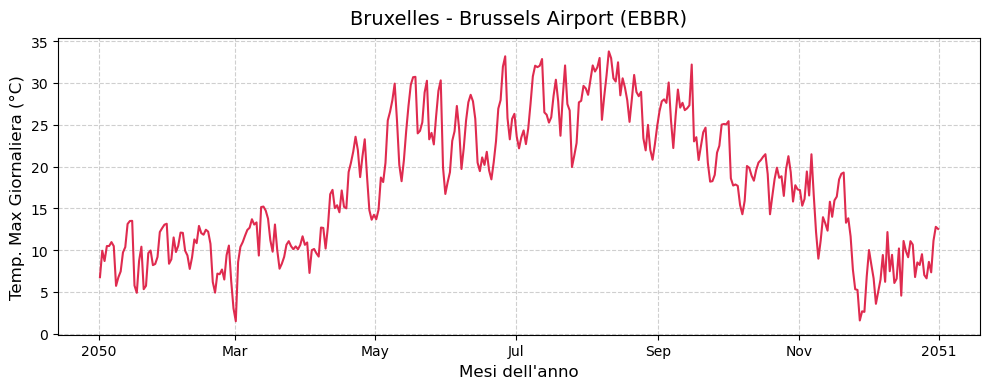

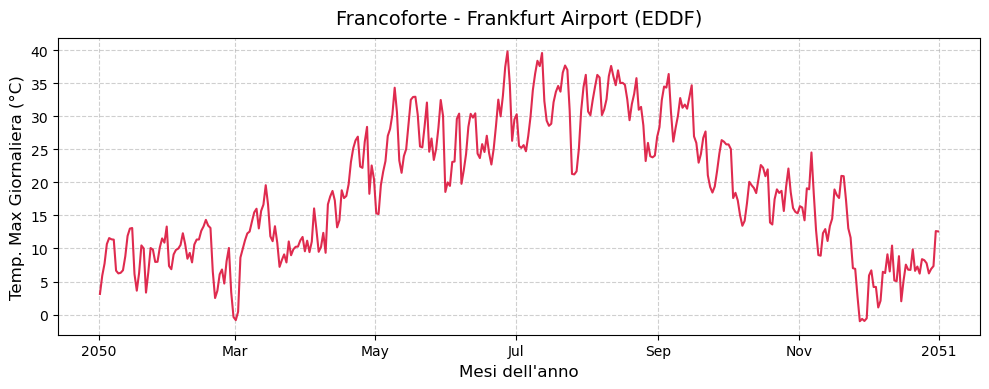

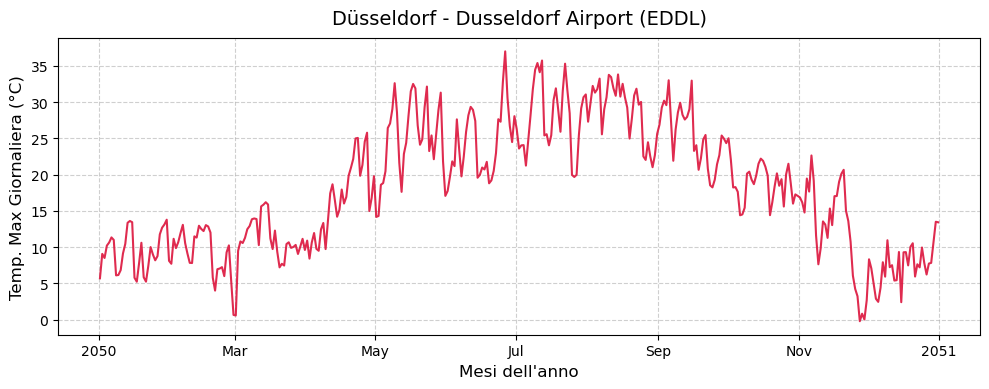

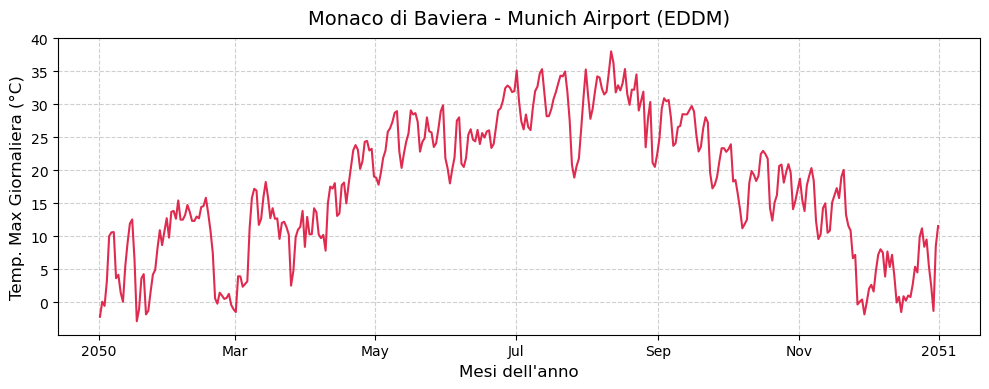

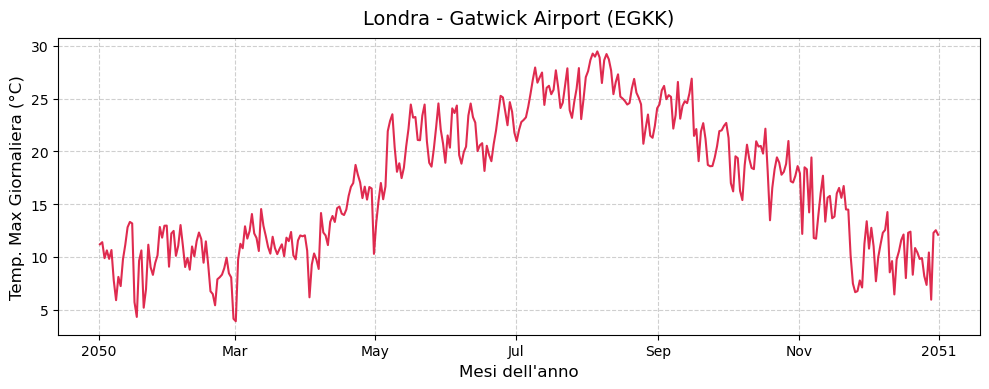

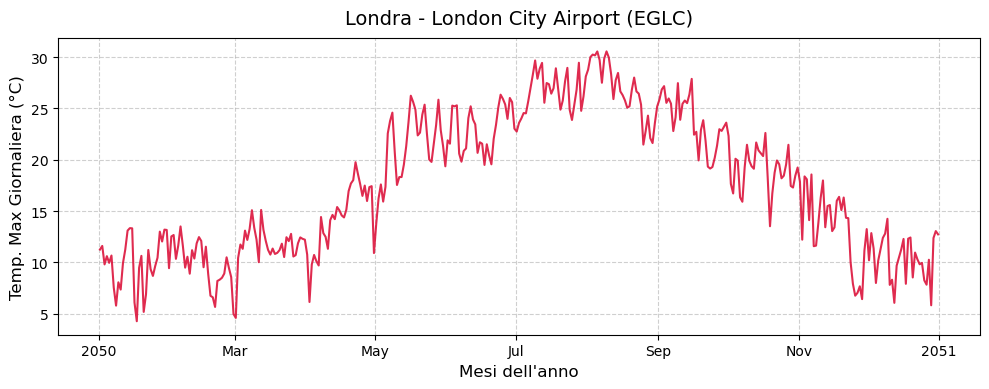

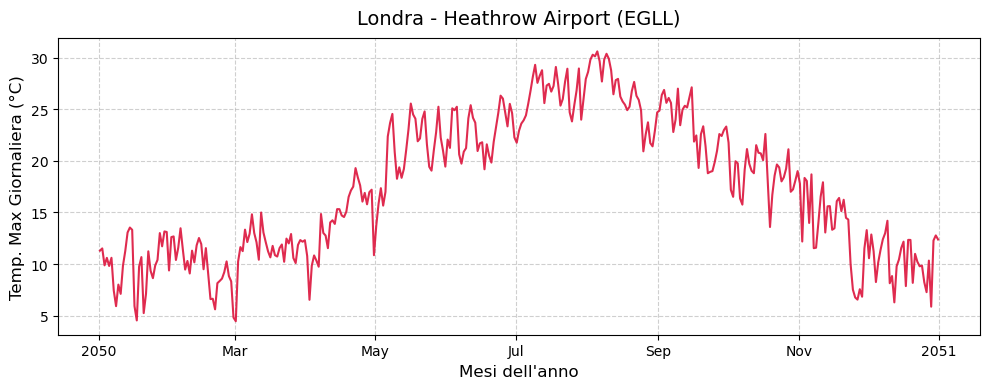

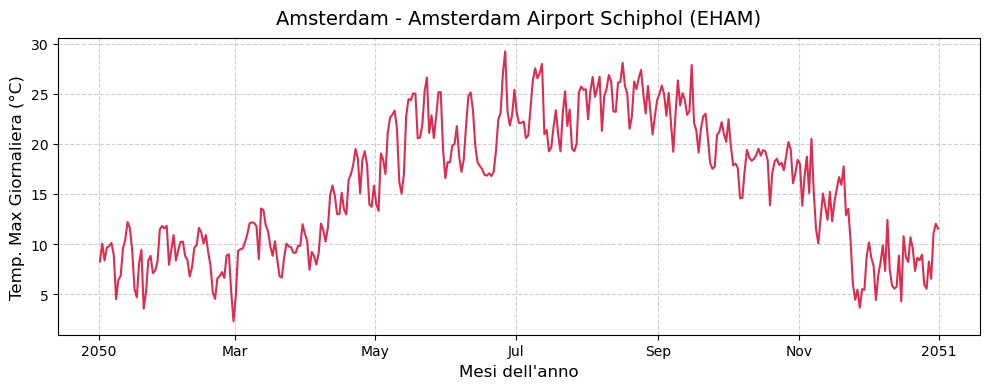

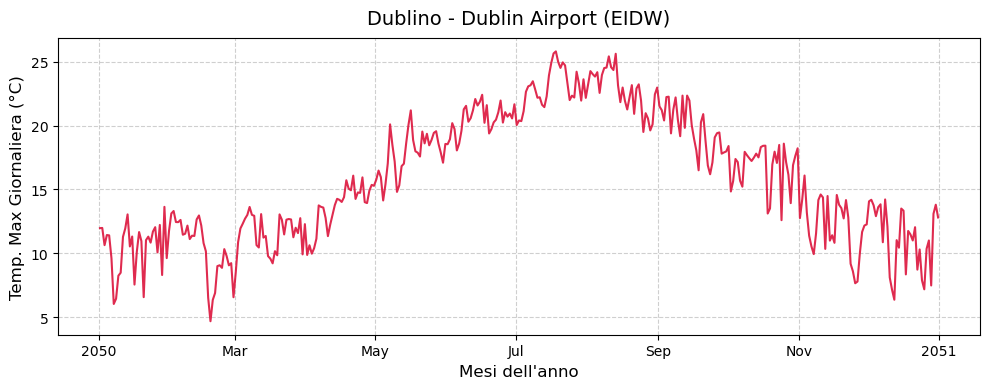

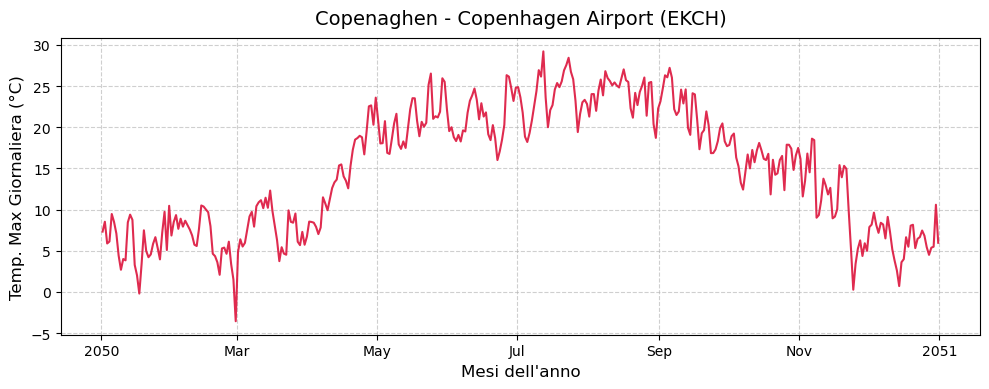

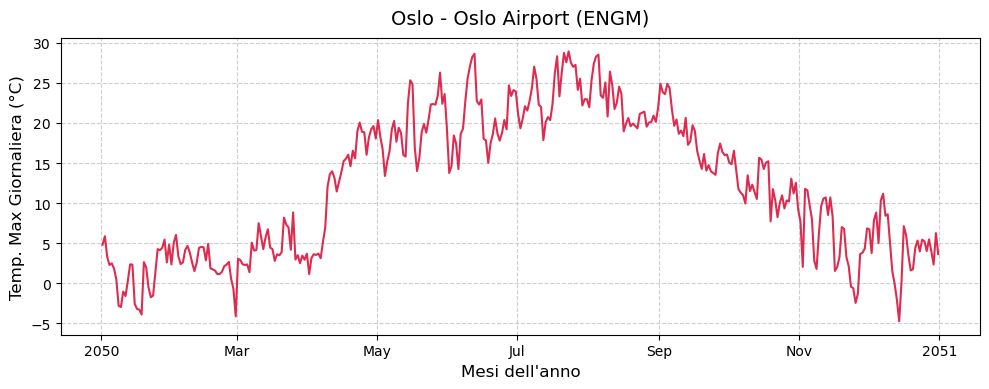

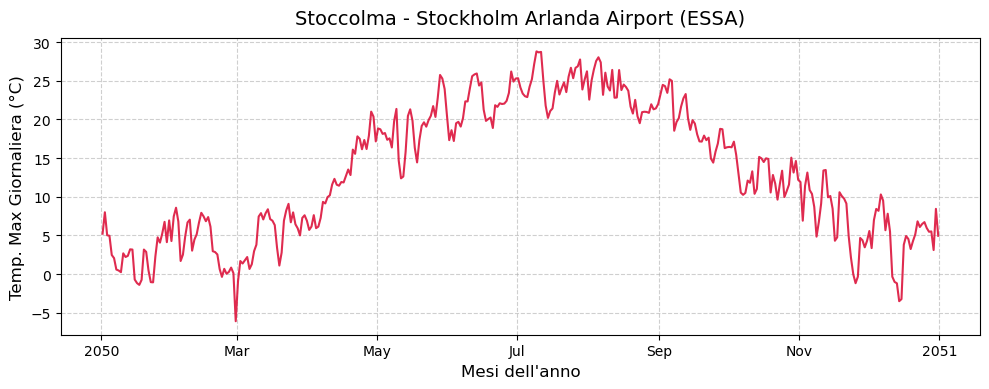

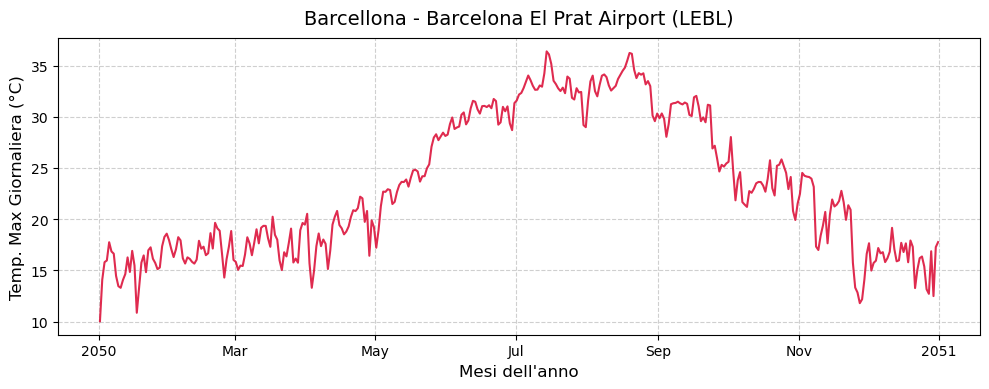

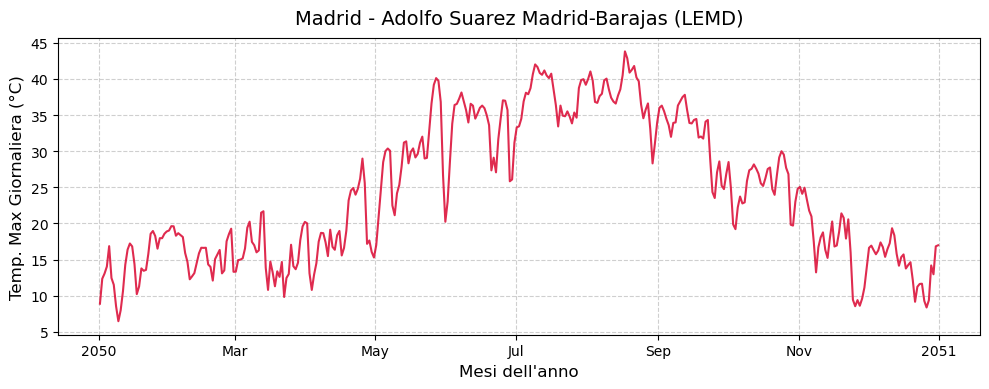

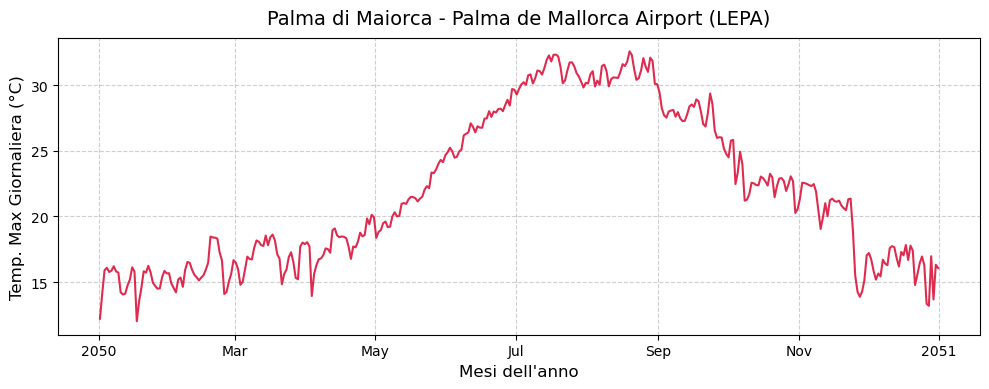

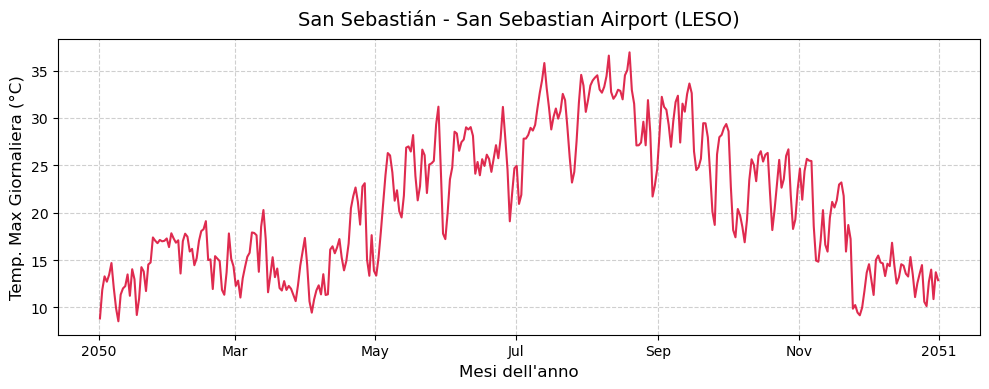

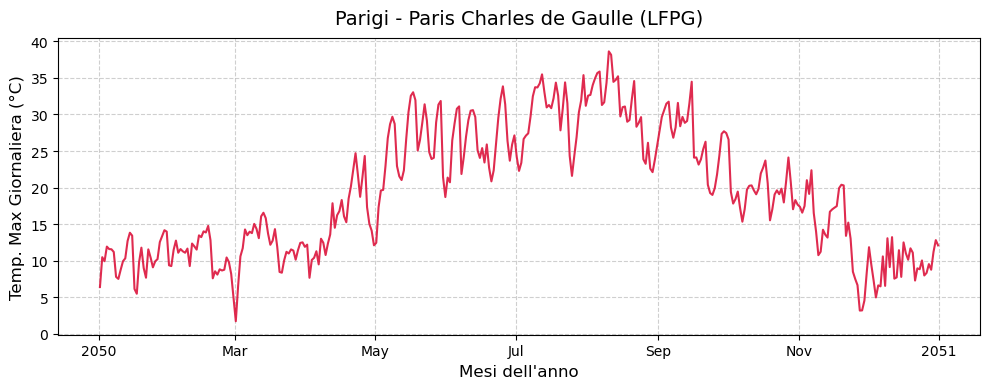

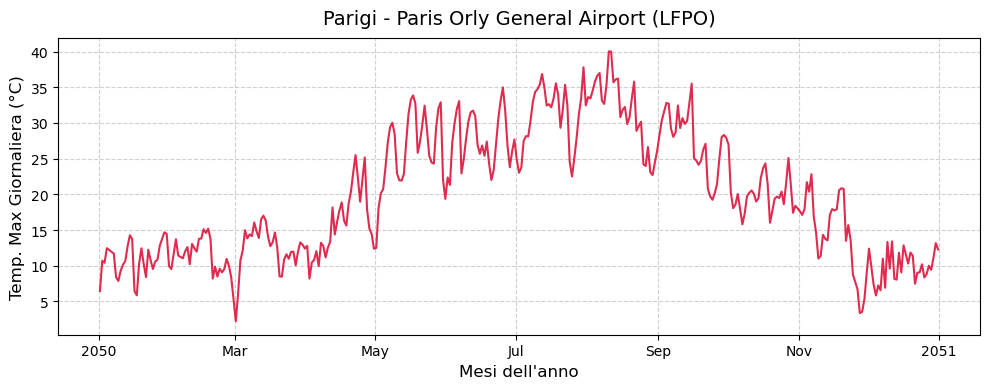

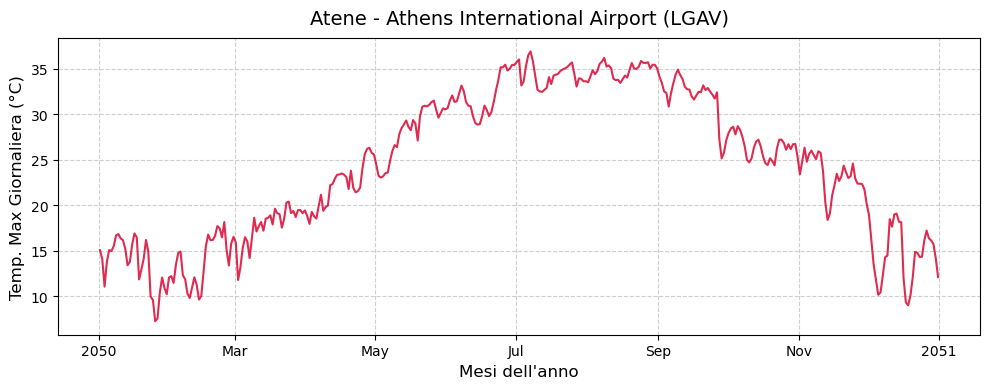

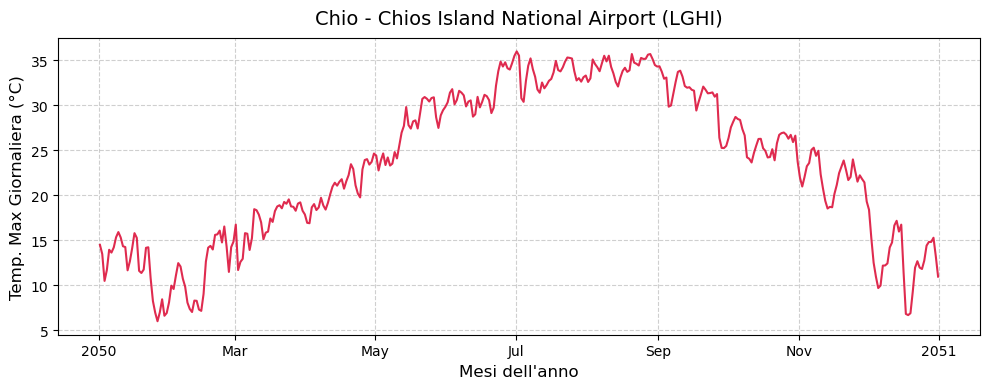

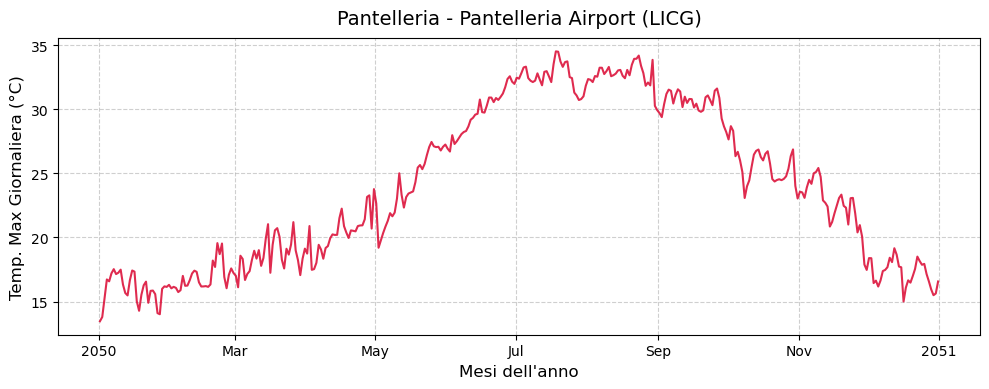

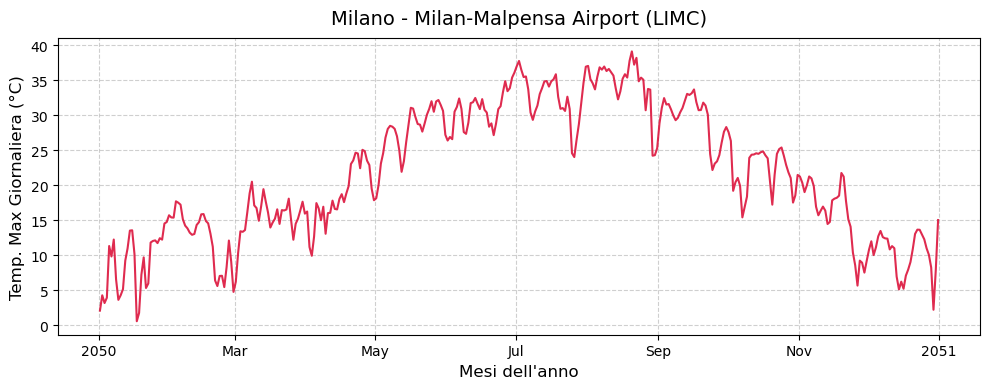

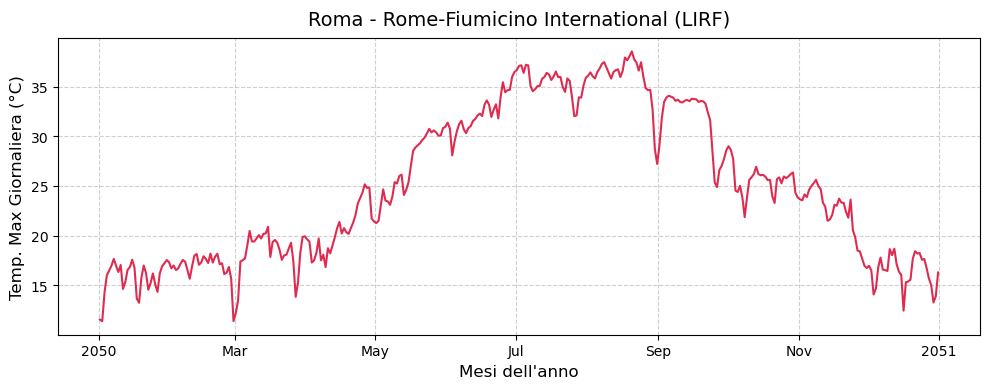

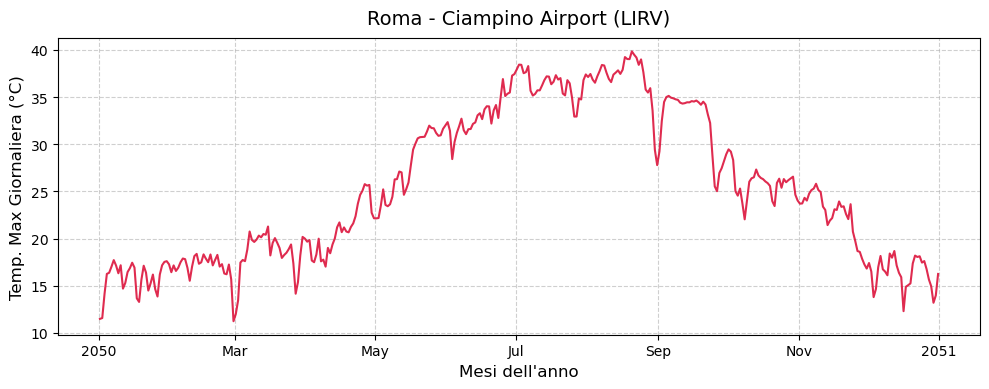

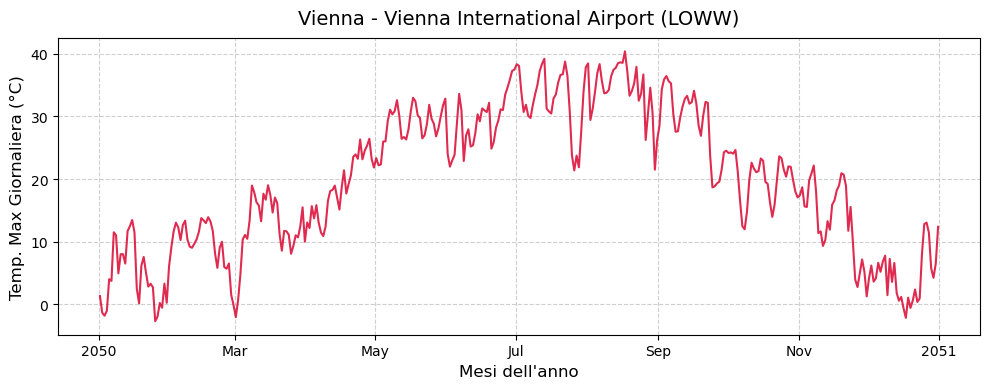

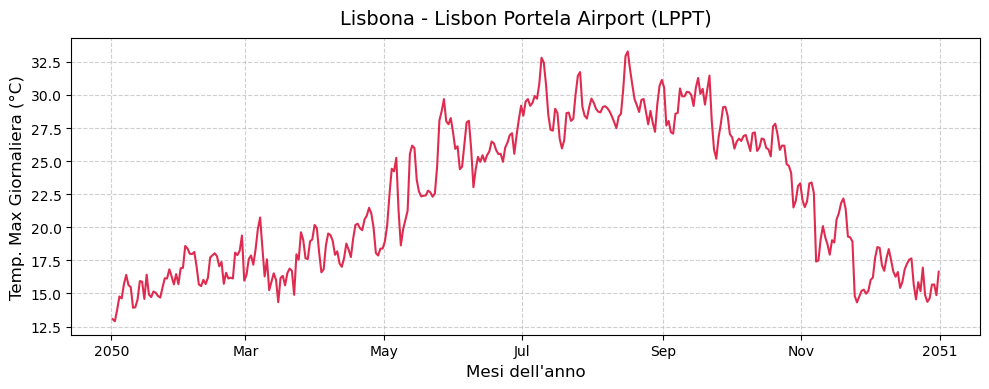

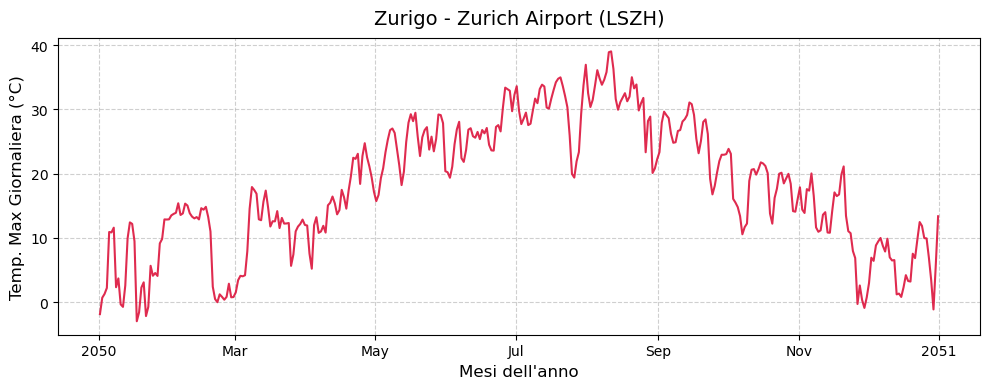

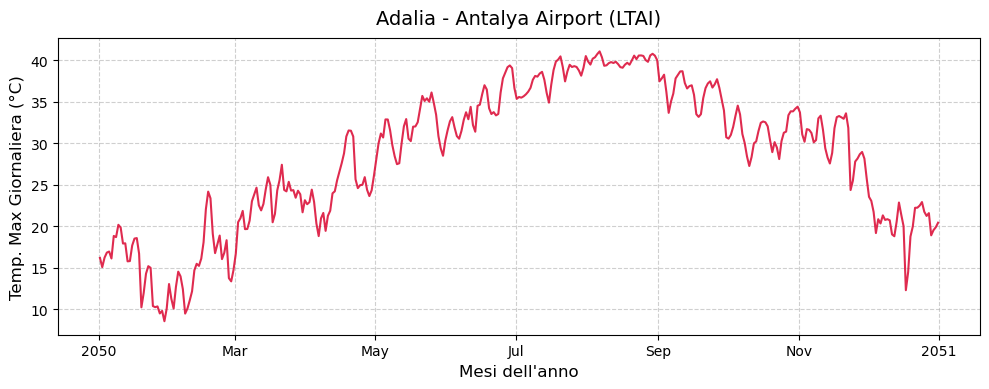

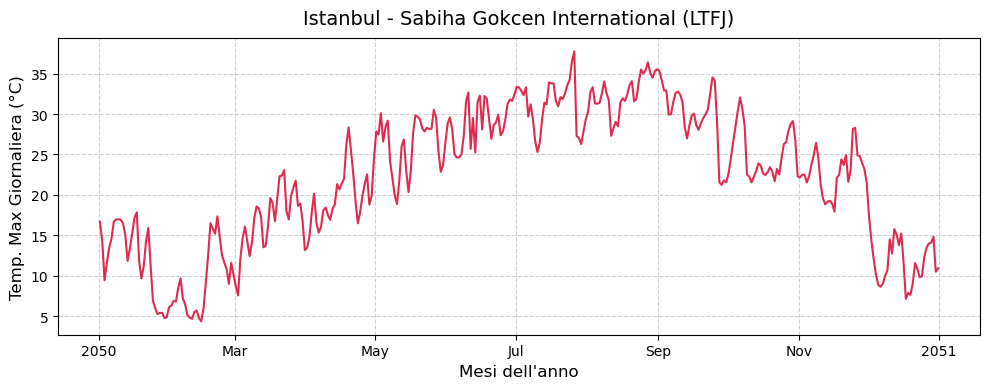

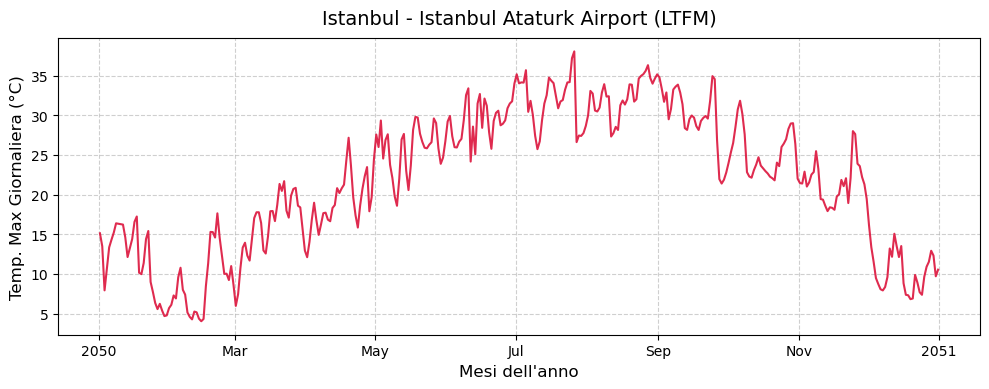

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# ==============================================================================
# 1. IMPOSTAZIONI DEL FILE
# ==============================================================================
file_storico = 'tasmax_day_ACCESS-ESM1-5_ssp585_r1i1p1f1_gn_2050.nc'

# ==============================================================================
# 2. DIZIONARIO DEI 30 AEROPORTI EUROPEI
# ==============================================================================
airports = {
    'EBBR': {'nome': 'Brussels Airport', 'citta': 'Bruxelles', 'lat': 50.9014, 'lon': 4.4844},
    'EDDF': {'nome': 'Frankfurt Airport', 'citta': 'Francoforte', 'lat': 50.0333, 'lon': 8.5706},
    'EDDL': {'nome': 'Dusseldorf Airport', 'citta': 'Düsseldorf', 'lat': 51.2895, 'lon': 6.7668},
    'EDDM': {'nome': 'Munich Airport', 'citta': 'Monaco di Baviera', 'lat': 48.3538, 'lon': 11.7861},
    'EGKK': {'nome': 'Gatwick Airport', 'citta': 'Londra', 'lat': 51.1481, 'lon': -0.1903},
    'EGLC': {'nome': 'London City Airport', 'citta': 'Londra', 'lat': 51.5053, 'lon': 0.0553},
    'EGLL': {'nome': 'Heathrow Airport', 'citta': 'Londra', 'lat': 51.4700, 'lon': -0.4543},
    'EHAM': {'nome': 'Amsterdam Airport Schiphol', 'citta': 'Amsterdam', 'lat': 52.3105, 'lon': 4.7683},
    'EIDW': {'nome': 'Dublin Airport', 'citta': 'Dublino', 'lat': 53.4264, 'lon': -6.2499},
    'EKCH': {'nome': 'Copenhagen Airport', 'citta': 'Copenaghen', 'lat': 55.6180, 'lon': 12.6560},
    'ENGM': {'nome': 'Oslo Airport', 'citta': 'Oslo', 'lat': 60.1939, 'lon': 11.1004},
    'ESSA': {'nome': 'Stockholm Arlanda Airport', 'citta': 'Stoccolma', 'lat': 59.6519, 'lon': 17.9186},
    'LEBL': {'nome': 'Barcelona El Prat Airport', 'citta': 'Barcellona', 'lat': 41.2974, 'lon': 2.0833},
    'LEMD': {'nome': 'Adolfo Suarez Madrid-Barajas', 'citta': 'Madrid', 'lat': 40.4839, 'lon': -3.5680},
    'LEPA': {'nome': 'Palma de Mallorca Airport', 'citta': 'Palma di Maiorca', 'lat': 39.5517, 'lon': 2.7388},
    'LESO': {'nome': 'San Sebastian Airport', 'citta': 'San Sebastián', 'lat': 43.3565, 'lon': -1.7906},
    'LFPG': {'nome': 'Paris Charles de Gaulle', 'citta': 'Parigi', 'lat': 49.0097, 'lon': 2.5479},
    'LFPO': {'nome': 'Paris Orly General Airport', 'citta': 'Parigi', 'lat': 48.7262, 'lon': 2.3652},
    'LGAV': {'nome': 'Athens International Airport', 'citta': 'Atene', 'lat': 37.9364, 'lon': 23.9445},
    'LGHI': {'nome': 'Chios Island National Airport', 'citta': 'Chio', 'lat': 38.3432, 'lon': 26.1406},
    'LICG': {'nome': 'Pantelleria Airport', 'citta': 'Pantelleria', 'lat': 36.8167, 'lon': 11.9689},
    'LIMC': {'nome': 'Milan-Malpensa Airport', 'citta': 'Milano', 'lat': 45.6301, 'lon': 8.7255},
    'LIRF': {'nome': 'Rome-Fiumicino International', 'citta': 'Roma', 'lat': 41.7999, 'lon': 12.2462},
    'LIRV': {'nome': 'Ciampino Airport', 'citta': 'Roma', 'lat': 41.7994, 'lon': 12.5949},
    'LOWW': {'nome': 'Vienna International Airport', 'citta': 'Vienna', 'lat': 48.1103, 'lon': 16.5697},
    'LPPT': {'nome': 'Lisbon Portela Airport', 'citta': 'Lisbona', 'lat': 38.7742, 'lon': -9.1342},
    'LSZH': {'nome': 'Zurich Airport', 'citta': 'Zurigo', 'lat': 47.4582, 'lon': 8.5555},
    'LTAI': {'nome': 'Antalya Airport', 'citta': 'Adalia', 'lat': 36.8987, 'lon': 30.8005},
    'LTFJ': {'nome': 'Sabiha Gokcen International', 'citta': 'Istanbul', 'lat': 40.8986, 'lon': 29.3092},
    'LTFM': {'nome': 'Istanbul Ataturk Airport', 'citta': 'Istanbul', 'lat': 41.2622, 'lon': 28.7420}
}

# ==============================================================================
# 3. CARICAMENTO DATI
# ==============================================================================
ds = xr.open_dataset(file_storico)
var_name = 'tasmax' if 'tasmax' in ds.data_vars else 't2m'

# ==============================================================================
# 4. LOOP SU TUTTI I 30 AEROPORTI E VISUALIZZAZIONE A SCHERMO
# ==============================================================================
for icao, info in airports.items():
    
    lat_aeroporto = info['lat']
    lon_aeroporto = info['lon']
    
    # Adattamento Longitudine
    lon_model = lon_aeroporto
    if lon_aeroporto < 0 and ds['lon'].max() > 180:
        lon_model = 360 + lon_aeroporto

    # Estrazione dei dati per l'aeroporto specifico
    da_local = ds[var_name].sel(lat=lat_aeroporto, lon=lon_model, method='nearest')

    # Conversione in Celsius se necessario
    if da_local.attrs.get('units') == 'K':
        da_local = da_local - 273.15
        da_local.attrs['units'] = '°C'

    # Creazione del grafico
    fig, ax = plt.subplots(figsize=(10, 4))
    da_local.plot(ax=ax, color='crimson', linewidth=1.5, alpha=0.9)

    plt.title(f"{info['citta']} - {info['nome']} ({icao})", fontsize=14, pad=10)
    plt.xlabel("Mesi dell'anno", fontsize=12)
    plt.ylabel("Temp. Max Giornaliera (°C)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # MOSTRA IL GRAFICO
    plt.show()